# Pre-processing

In [1]:
# Details of dataset

# YEAR : year of the flight trip
# MONTH : Month of the flight trip
# DAY : day of the flight trip
# DAY_OF_WEEK : Day of week of the Flight Trip
# AIRLINE : Airline Identifier
# FLIGHT_NUMBER : Airline Identifier A flight number identifies a specific flight route operated by an airline.
# 'TAIL_NUMBER' : Aircraft Identifier
# 'ORIGIN_AIRPORT' : Starting Airport
# 'DESTINATION_AIRPORT' : Destination Airport
# 'SCHEDULED_DEPARTURE' : Planned Departure Time
# 'DEPARTURE_TIME' : WHEEL_OFF - TAXI_OUT
# 'DEPARTURE_DELAY' : Total Delay on Departure
# 'TAXI_OUT': The time duration elapsed between departure from the origin airport gate and wheels off
# 'WHEELS_OFF' : The time point that the aircraft's wheels leave the ground
# 'SCHEDULED_TIME' : Planned time amount needed for the flight trip
# 'ELAPSED_TIME' : AIR_TIME+TAXI_IN+TAXI_OUT
# 'AIR_TIME' : The time duration between wheels_off and wheels_on time
# 'DISTANCE' : Distance between two airports
# 'WHEELS_ON' : The time point that the aircraft's wheels touch on the ground
# 'TAXI_IN' : The time duration elapsed between wheels-on and gate arrival at the destination airport
# 'SCHEDULED_ARRIVAL' : Planned arrival time
# 'ARRIVAL_TIME' : WHEELS_ON+TAXI_IN
# 'ARRIVAL_DELAY' : ARRIVAL_TIME-SCHEDULED_ARRIVAL 
                        # Positive value → Flight arrived late.
                        # Negative value → Flight arrived early.
                        # Zero → Flight arrived exactly on time.
# 'DIVERTED': Aircraft landed on airport that out of schedule
                        # 0 = Not diverted
                        # 1 = Diverted
# 'CANCELLED' : Flight Cancelled (1 = cancelled)
# "CANCELLATION_REASON' : Reason for Cancellation of flight: A - Airline/Carrier; B - Weather; C - National Air System; D - Security
# 'AIR_SYSTEM_DELAY' : Delay caused by air system
# 'SECURITY_DELAY': Delay caused by security
# 'AIRLINE_DELAY' : Delay caused by the airline
# 'LATE_AIRCRAFT_DELAY' : Delay caused by aircraft
# 'WEATHER_DELAY' : Delay caused by weather

In [2]:
#import required libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

D:\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
# import dataset

data = pd.read_csv("flights.csv")
data.head()

C:\Users\Ashtekar\AppData\Local\Temp\ipykernel_5140\440243808.py:3: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("flights.csv")


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
data.tail()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,2359,...,753.0,-26.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,2359,...,430.0,-16.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,2359,...,432.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,2359,...,330.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819078,2015,12,31,4,B6,839,N534JB,JFK,BQN,2359,...,442.0,2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# list of columns 
columns = data.columns
columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')

In [8]:
# shape of the data
data.shape

(5819079, 31)

In [9]:
# data types
data.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

In [10]:
# data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [11]:
# mean, median mode 
data.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


In [12]:
data.describe(include = 'object')

,AIRLINE,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,CANCELLATION_REASON
count,5819079,5804358,5819079,5819079,89884
unique,14,4897,930,930,4
top,WN,N480HA,ATL,ATL,B
freq,1261855,3768,346836,346904,48851


In [ ]:
#Interpretation


In [13]:
# missing values
missing = pd.DataFrame({
    'Missing Values' : data.isnull().sum(),
    'Percentage' : (data.isnull().sum()/len(data))*100
})

missing.sort_values(by = 'Percentage', ascending = False)

,Missing Values,Percentage
CANCELLATION_REASON,5729195,98.455357
WEATHER_DELAY,4755640,81.724960
LATE_AIRCRAFT_DELAY,4755640,81.724960
AIRLINE_DELAY,4755640,81.724960
SECURITY_DELAY,4755640,81.724960
AIR_SYSTEM_DELAY,4755640,81.724960
AIR_TIME,105071,1.805629
ARRIVAL_DELAY,105071,1.805629
ELAPSED_TIME,105071,1.805629
WHEELS_ON,92513,1.589822


In [14]:
#Handling Missing Values

# Fill delay-cause columns with 0
delay_cols = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]

data[delay_cols] = data[delay_cols].fillna(0)

# Fill cancellation reason
data['CANCELLATION_REASON'] = data['CANCELLATION_REASON'].fillna('Not Cancelled')

# Remove rows with only 1 missing value in essential columns
data = data.dropna(subset=[
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE',
    'SCHEDULED_TIME',
    'DISTANCE'
])

In [8]:
# unique values 
data.nunique()

YEAR                      1
MONTH                    12
DAY                      31
DAY_OF_WEEK               7
AIRLINE                  14
FLIGHT_NUMBER          6952
TAIL_NUMBER            4897
ORIGIN_AIRPORT          930
DESTINATION_AIRPORT     930
SCHEDULED_DEPARTURE    1321
DEPARTURE_TIME         1440
DEPARTURE_DELAY        1217
TAXI_OUT                184
WHEELS_OFF             1440
SCHEDULED_TIME          550
ELAPSED_TIME            712
AIR_TIME                675
DISTANCE               1363
WHEELS_ON              1440
TAXI_IN                 185
SCHEDULED_ARRIVAL      1435
ARRIVAL_TIME           1440
ARRIVAL_DELAY          1240
DIVERTED                  2
CANCELLED                 2
CANCELLATION_REASON       4
AIR_SYSTEM_DELAY        570
SECURITY_DELAY          154
AIRLINE_DELAY          1067
LATE_AIRCRAFT_DELAY     695
WEATHER_DELAY           632
dtype: int64

In [15]:
# duplicate rows
data.duplicated().sum()

0

In [16]:
# Separate Numerical and Categorical columns

num_cols = data.select_dtypes(include = np.number).columns

cat_cols = data.select_dtypes(include = 'object').columns

# EDA

# Histogram

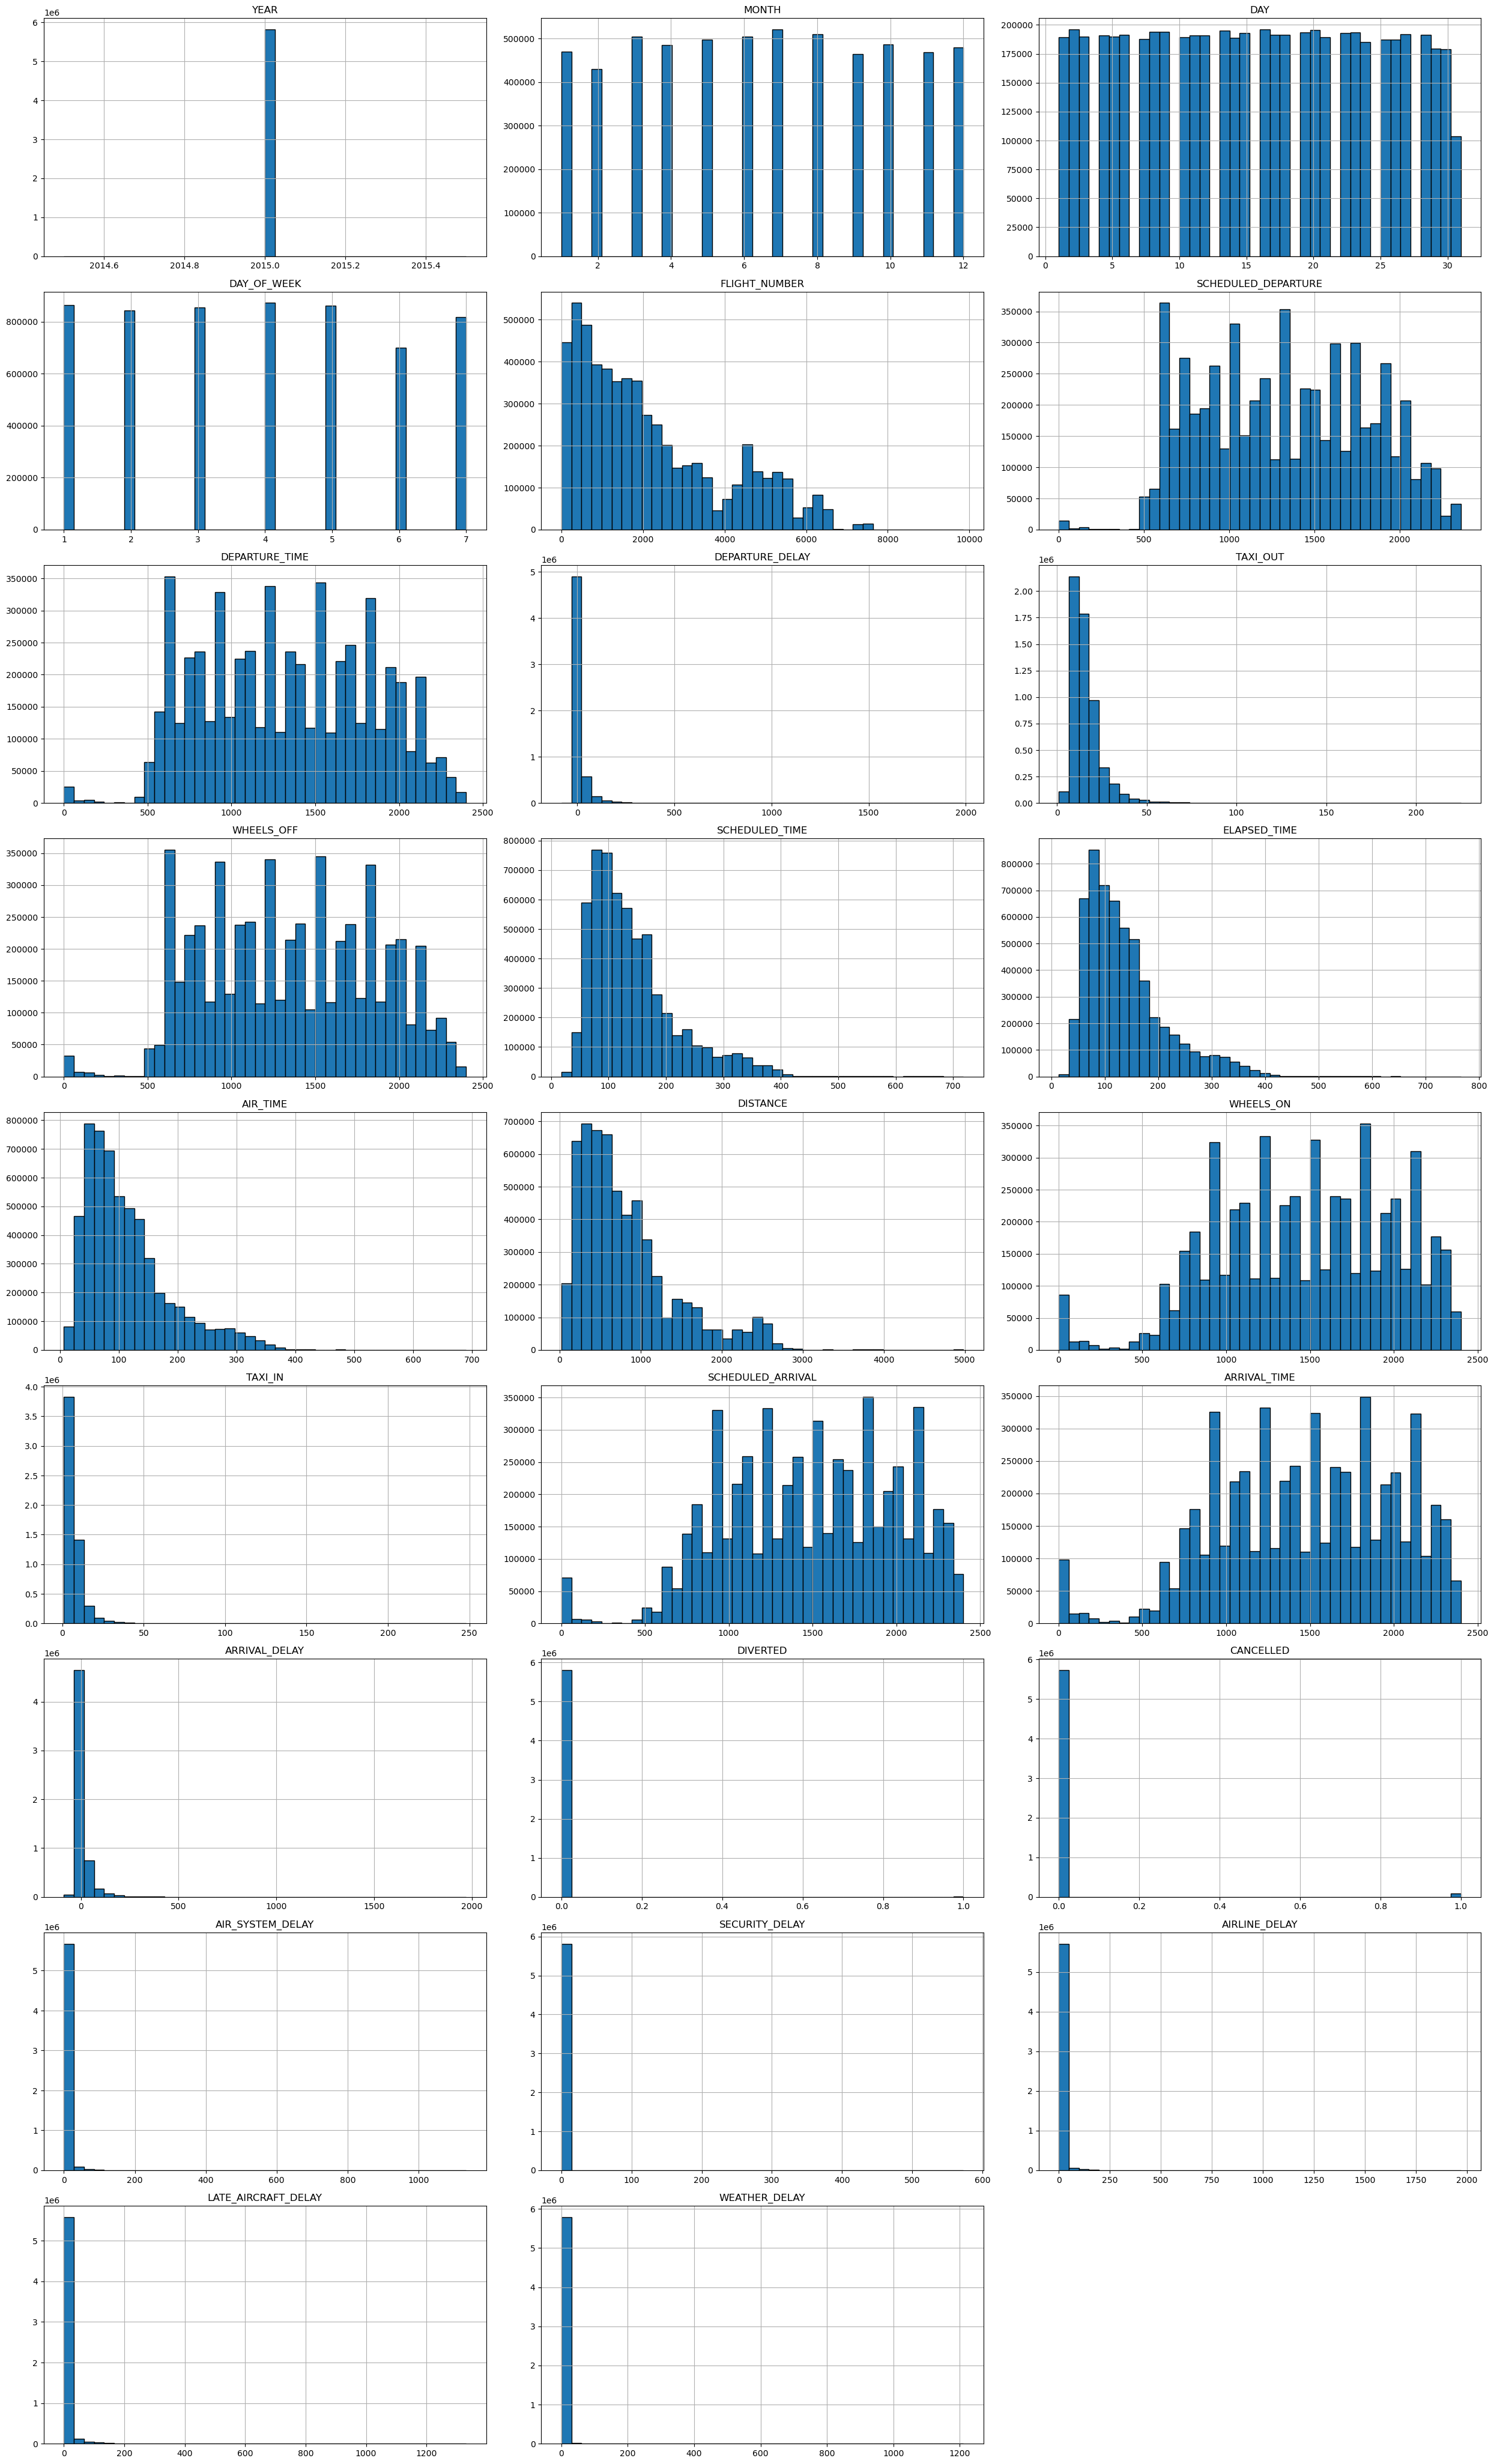

In [17]:
# Ploting histogram for each column to understand the skewness of the data

data.hist(bins = 40, figsize = (25,50),layout = (11,3), edgecolor = 'black')

# Clean up the layout and display
plt.tight_layout()
plt.show()

# Interpretation:

-- 1) The dataset contains flights from only one year (2015).

-- 2) Flights distributed uniformly across all 12 months. 

     Monly count of flights ranging approximately from 4,00,000 to 5,00,000
     
     Slightly more flights occurs in month june to august, likely due to Summer Vacations
     
-- 3) Flights has been evenly distributed across all the day from 1 to 30.
      
      Slighlty fewer flights occurs on day 31, since only 7 months contains 31st day.
      
-- 4) Day 1 to 5 has similar number of flights.
      
      Day 6 ( Saturday) has fewer flights, since saturday is typically least busy travel day for business.
      
      Day 7 ( Sunday) has increase in flights again.
  
--5) A flight number identifies a specific flight route operated by an airline.
     
     The flights with flight number > = 2000 have the lower flights.
     
     We can say that Airlines assign lower numbers to more common routes and High-numbered flights are relatively rare.
     
     
     Many airlines assign:

        Lower flight numbers to frequently operated or major routes.
        Higher flight numbers to less frequent, regional, seasonal, or special flights.

        However, this depends on the airline and is not a universal rule.
        
-- 6) Flights occur throughout the day.

        Multiple peaks are visible.

        Most of the flights's departure is scheduled early in the Morning from 5 AM till Mid-day 15 PM.
        
        Very few overnight departures.
        
-- 7) Actual departure times closely resemble scheduled departures.
      
      Similar multimodal distribution.  Airlines generally follow scheduled operations.
       
      Few departures occur between midnight and 5 AM.
      
-- 8) Most flights depart on time or only slightly late.
       
     A small number experience extremely large delays upto 2000 minutes delay i.e. approximately 33 hours delay.
     
     It might be possible due to technical issues or bad weather issues.

-- 9) Taxi-out is the time from when the aircraft pushes back from the departure gate until it takes off from the runway.

     Most flights have a taxi-out time of about 5–20 minutes. The distribution is right-skewed.
    
    A few flights have taxi-out times exceeding 100–200 minutes, which are unusual and likely due 
    to severe congestion, weather, or operational disruptions.

-- 10) Most takeoffs occur between 6:00 AM and 10:00 PM.
       
      There are multiple peaks throughout the day.
        
      Very few flights take off late at night or early morning.
    
-- 11) SCHEDULED_TIME: The distribution is right-skewed, with most flights scheduled to last between 60 and 180 minutes. 

       Longer scheduled times correspond to long-haul flights, while the right tail represents relatively few cros-country 
       
       or extended-distance routes.
       
-- 12) ELAPSED_TIME: Most flights have an actual travel time between 60 and 180 minutes. 

        The right-skewed distribution indicates that while most flights are completed within a few hours.
        
        A small number require substantially longer travel times due to long-distance routes or operational delays.
        
--13) AIR_TIME: The majority of flights spend less than 150 minutes in the air, indicating that the dataset is dominated by 

    short- and medium-haul flights. 

    The right-skewed distribution reflects the relatively small number of long-haul flights.
    
-- 14)DISTANCE : The distribution is positively skewed,with most flights covering short to medium distances i.e 200 to 1000 
    miles.

    Long-distance flights i.e. distance > 1000 miles are comparatively rare, resulting in a long right tail.
   
-- 15) WHEELS_ON: Landing times are concentrated during daytime and evening hours. 

    It showing multiple peaks that correspond to scheduled flight arrivals.

    Overnight arrivals occur much less frequently.
    
-- 16) TAXI_IN: Extremely right-skewed. Most values are below 15 minutes.
       
       Few observations exceed 50 minutes.
     
-- 17) SCHEDULED_ARRIVAL: Scheduled arrival times are distributed across the day, with noticeable peaks reflecting airline 

     scheduling patterns. Overnight scheduled arrivals are relatively uncommon.
     
-- 18) ARRIVAL_TIME: Actual arrival times closely follow the distribution of scheduled arrivals. 

     It indicating that most flights arrive within expected operational time windows despite some delays.
     
-- 19) ARRIVAL_DELAY: The distribution is highly right-skewed, with most flights arriving on time or experiencing only 
       minor delays. 

      A small number of flights have exceptionally long arrival delays, creating a long right tail. 

      These extreme values likely correspond to severe weather, operational disruptions, or airport congestion.
      
-- 20) DIVERTED: This binary variable is highly imbalanced, with high majority of flights completing their scheduled route. 

        Only a very small proportion of flights are diverted, indicating that diversions are rare events.
        
-- 21) CANCELLED: The distribution is highly imbalanced, with most scheduled flights operating normally.

      Flight cancellations represent only a small percentage of the dataset.
      
-- 22) AIR_SYSTEM_DELAY: Most flights experience no air system delay. 
        
       When delays occur, they are generally short, although a small number of flights encounter substantial delays due to 
       congestion or air traffic control restrictions.
       
-- 23) SECURITY_DELAY: Security-related delays are extremely uncommon.(Security screening Security incidents Passenger security checks) 
        
       Nearly all flights experience no security delay, indicating that security incidents contribute minimally to overall flight delays.
       
-- 24) AIRLINE_DELAY: Airline-related delays are generally minimal for most flights. 

        However, the right-skewed distribution indicates that a small number of flights experience substantial delays due to airline operational issues.
        
        e.g. Late crew arrival, Aircraft maintenance, Cleaning, Boarding delays
        
-- 25) LATE_AIRCRAFT_DELAY: This occurs when the aircraft assigned to your flight arrives late from its previous flight.
        
        Most flights are not affected by late-arriving aircraft. 

        However, a small number of flights experience significant delays that propagate from earlier flights using the same aircraft.
        
-- 26) WEATHER_DELAY: Weather-related delays are infrequent, with most flights unaffected.
        
       When adverse weather like fog, snow, thunderstrom, heavy rains, strong winds occurs, delays can become substantial, resulting in a highly right-skewed distribution.

# Count Plot

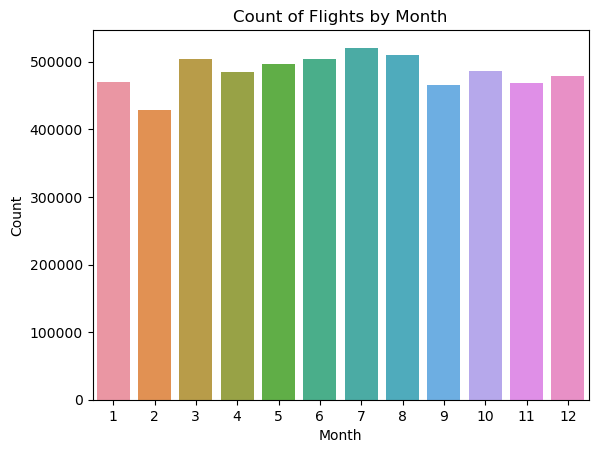

In [19]:
sns.countplot(data = data, x = 'MONTH')
plt.title("Count of Flights by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

####  All the months have good number of flights. The flights number increases from May to August month likely due to Summer Vacation

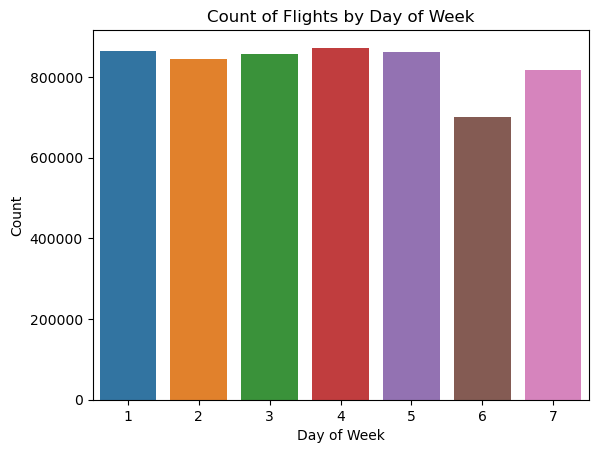

In [20]:
sns.countplot(data = data, x = 'DAY_OF_WEEK')
plt.title("Count of Flights by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.show()

### All the days are equally busy except day 6 i.e., Saturday

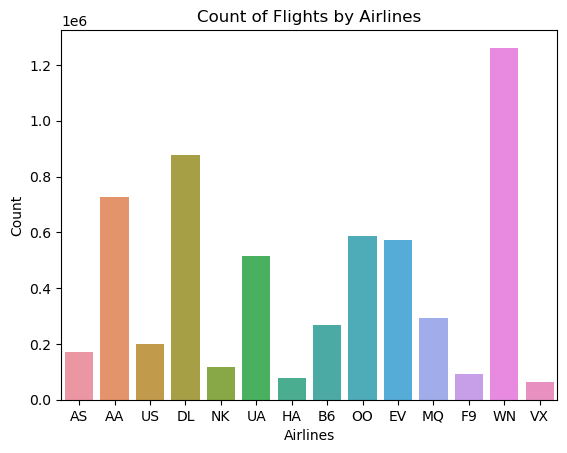

In [22]:
sns.countplot(data = data, x = 'AIRLINE')
plt.title("Count of Flights by Airlines")
plt.xlabel("Airlines")
plt.ylabel("Count")
plt.show()

### WN and DL contains the highest flights. VX route is the lowest flights
##### DL: Delta Air Lines
##### WN: Southwest Airlines
##### VX: Virgin America

# Box Plot

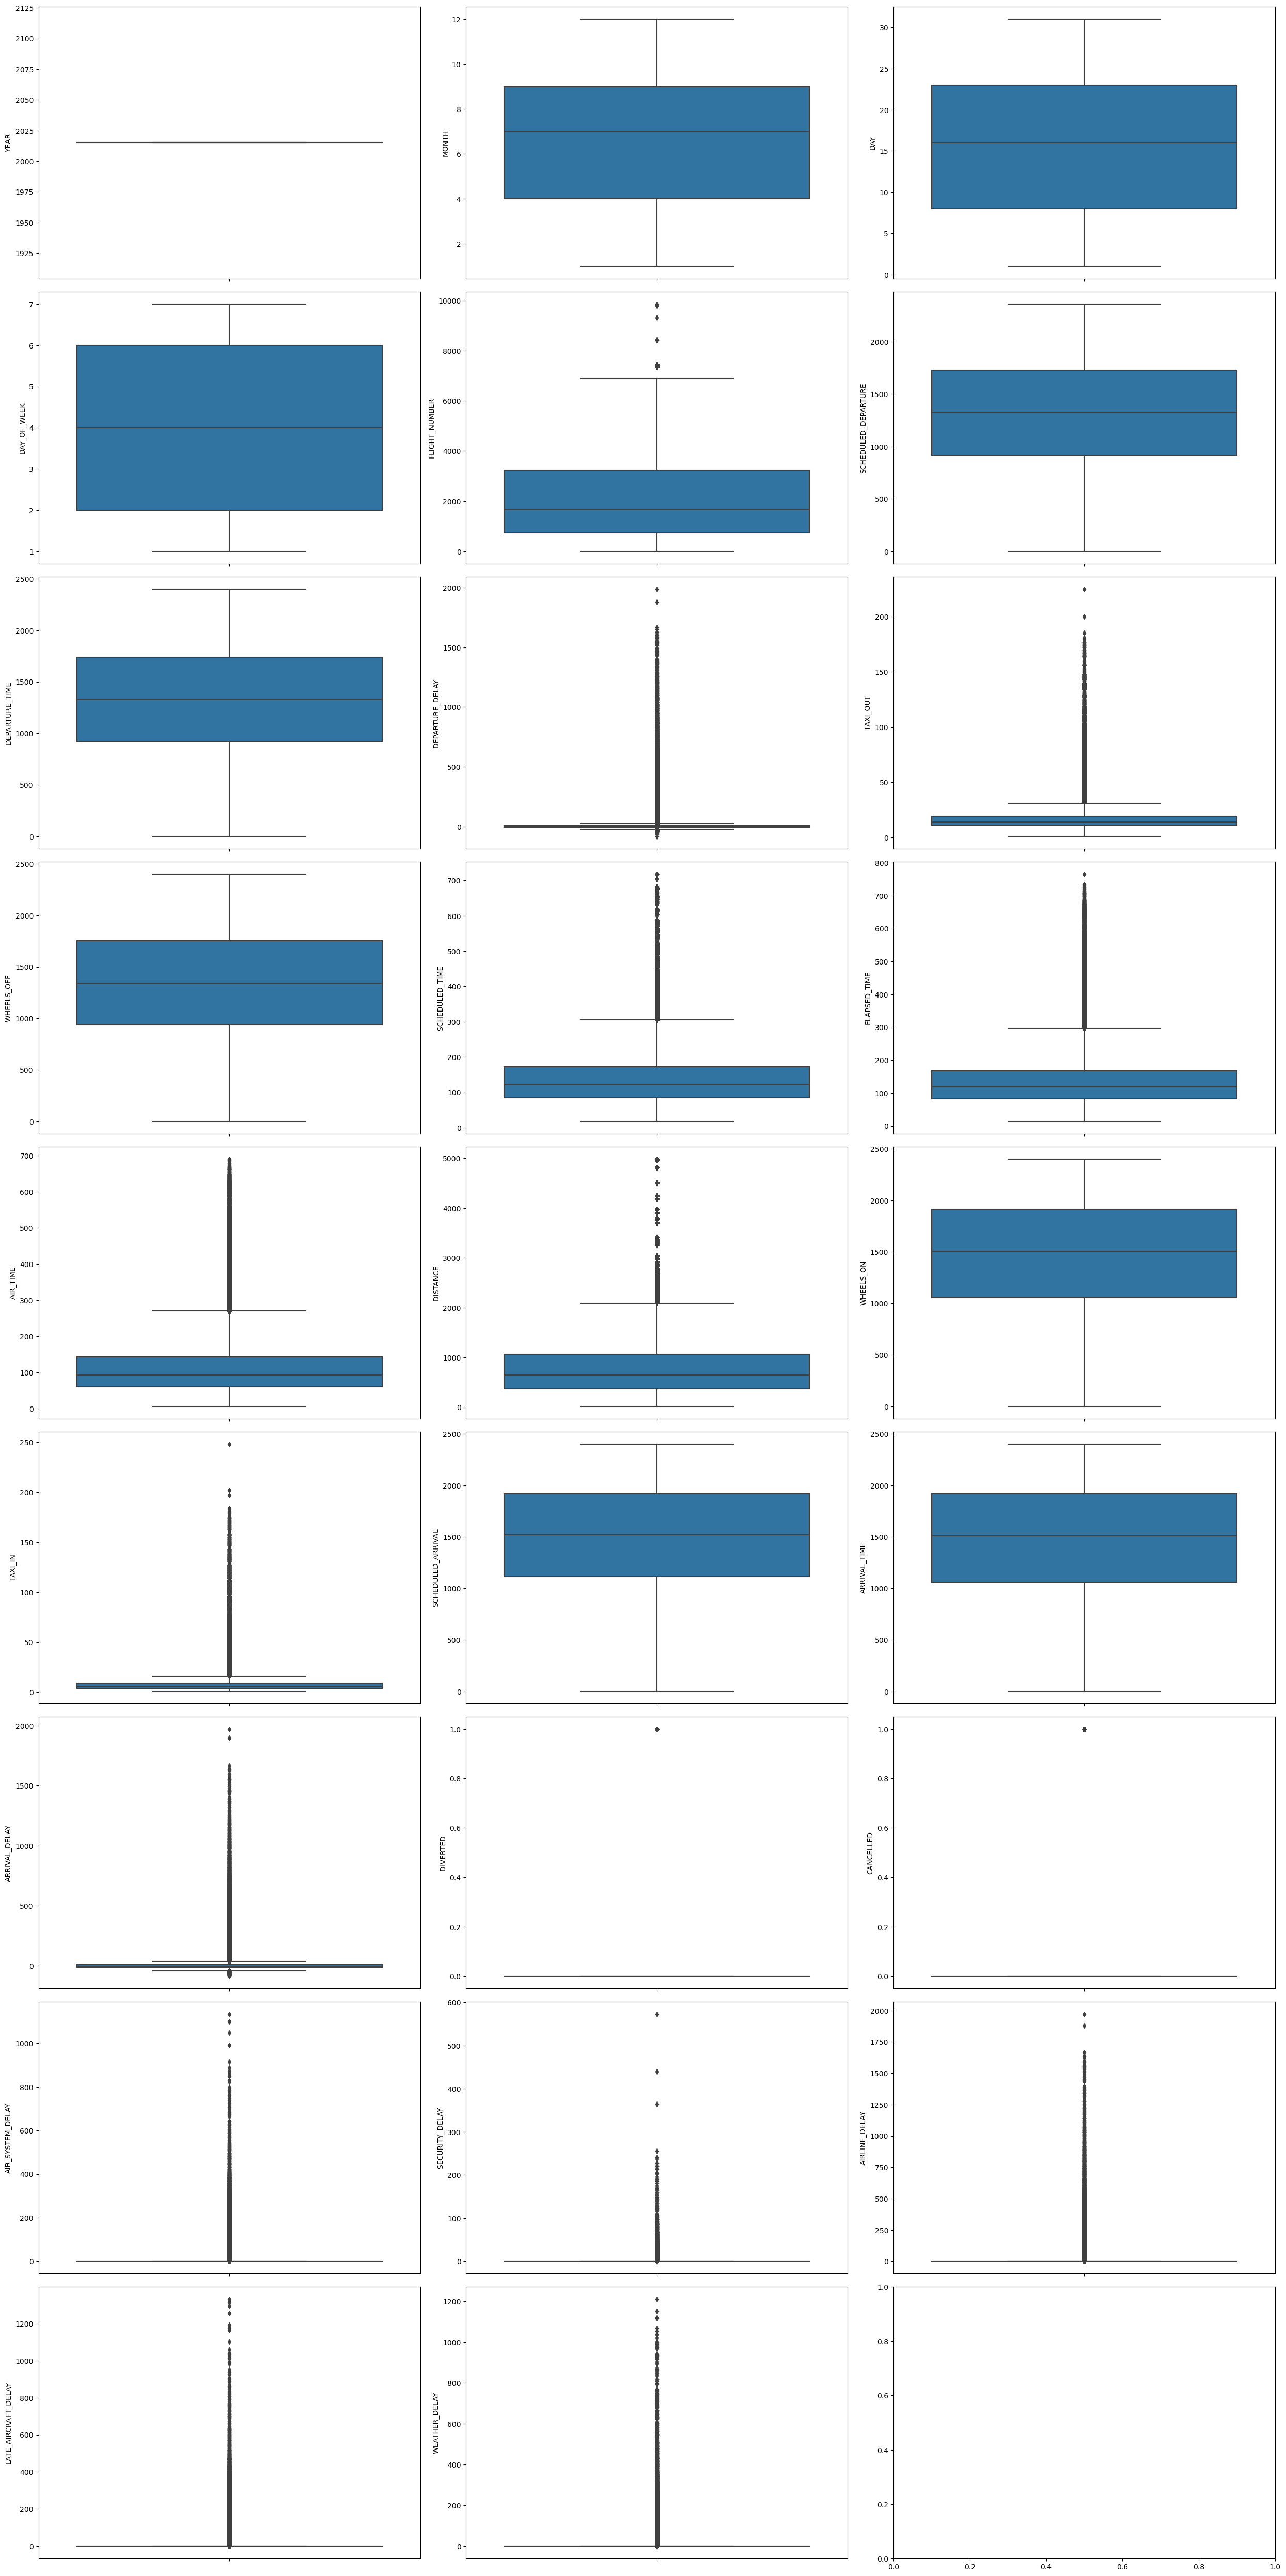

In [33]:
fig, axes = plt.subplots(9,3, figsize=(25,50))

axes = axes.flatten()

for i,col in enumerate(num_cols):
    sns.boxplot(y=data[col], ax=axes[i])

plt.tight_layout()

### There might seems many outliers, but those are the extreme cases for delays and cancellations due to weather issues, technical issue.

- Airline datasets such as the U.S. Department of Transportation (DOT) on-time performance data have recorded delays exceeding 24 hours for some flights.

# HeatMap

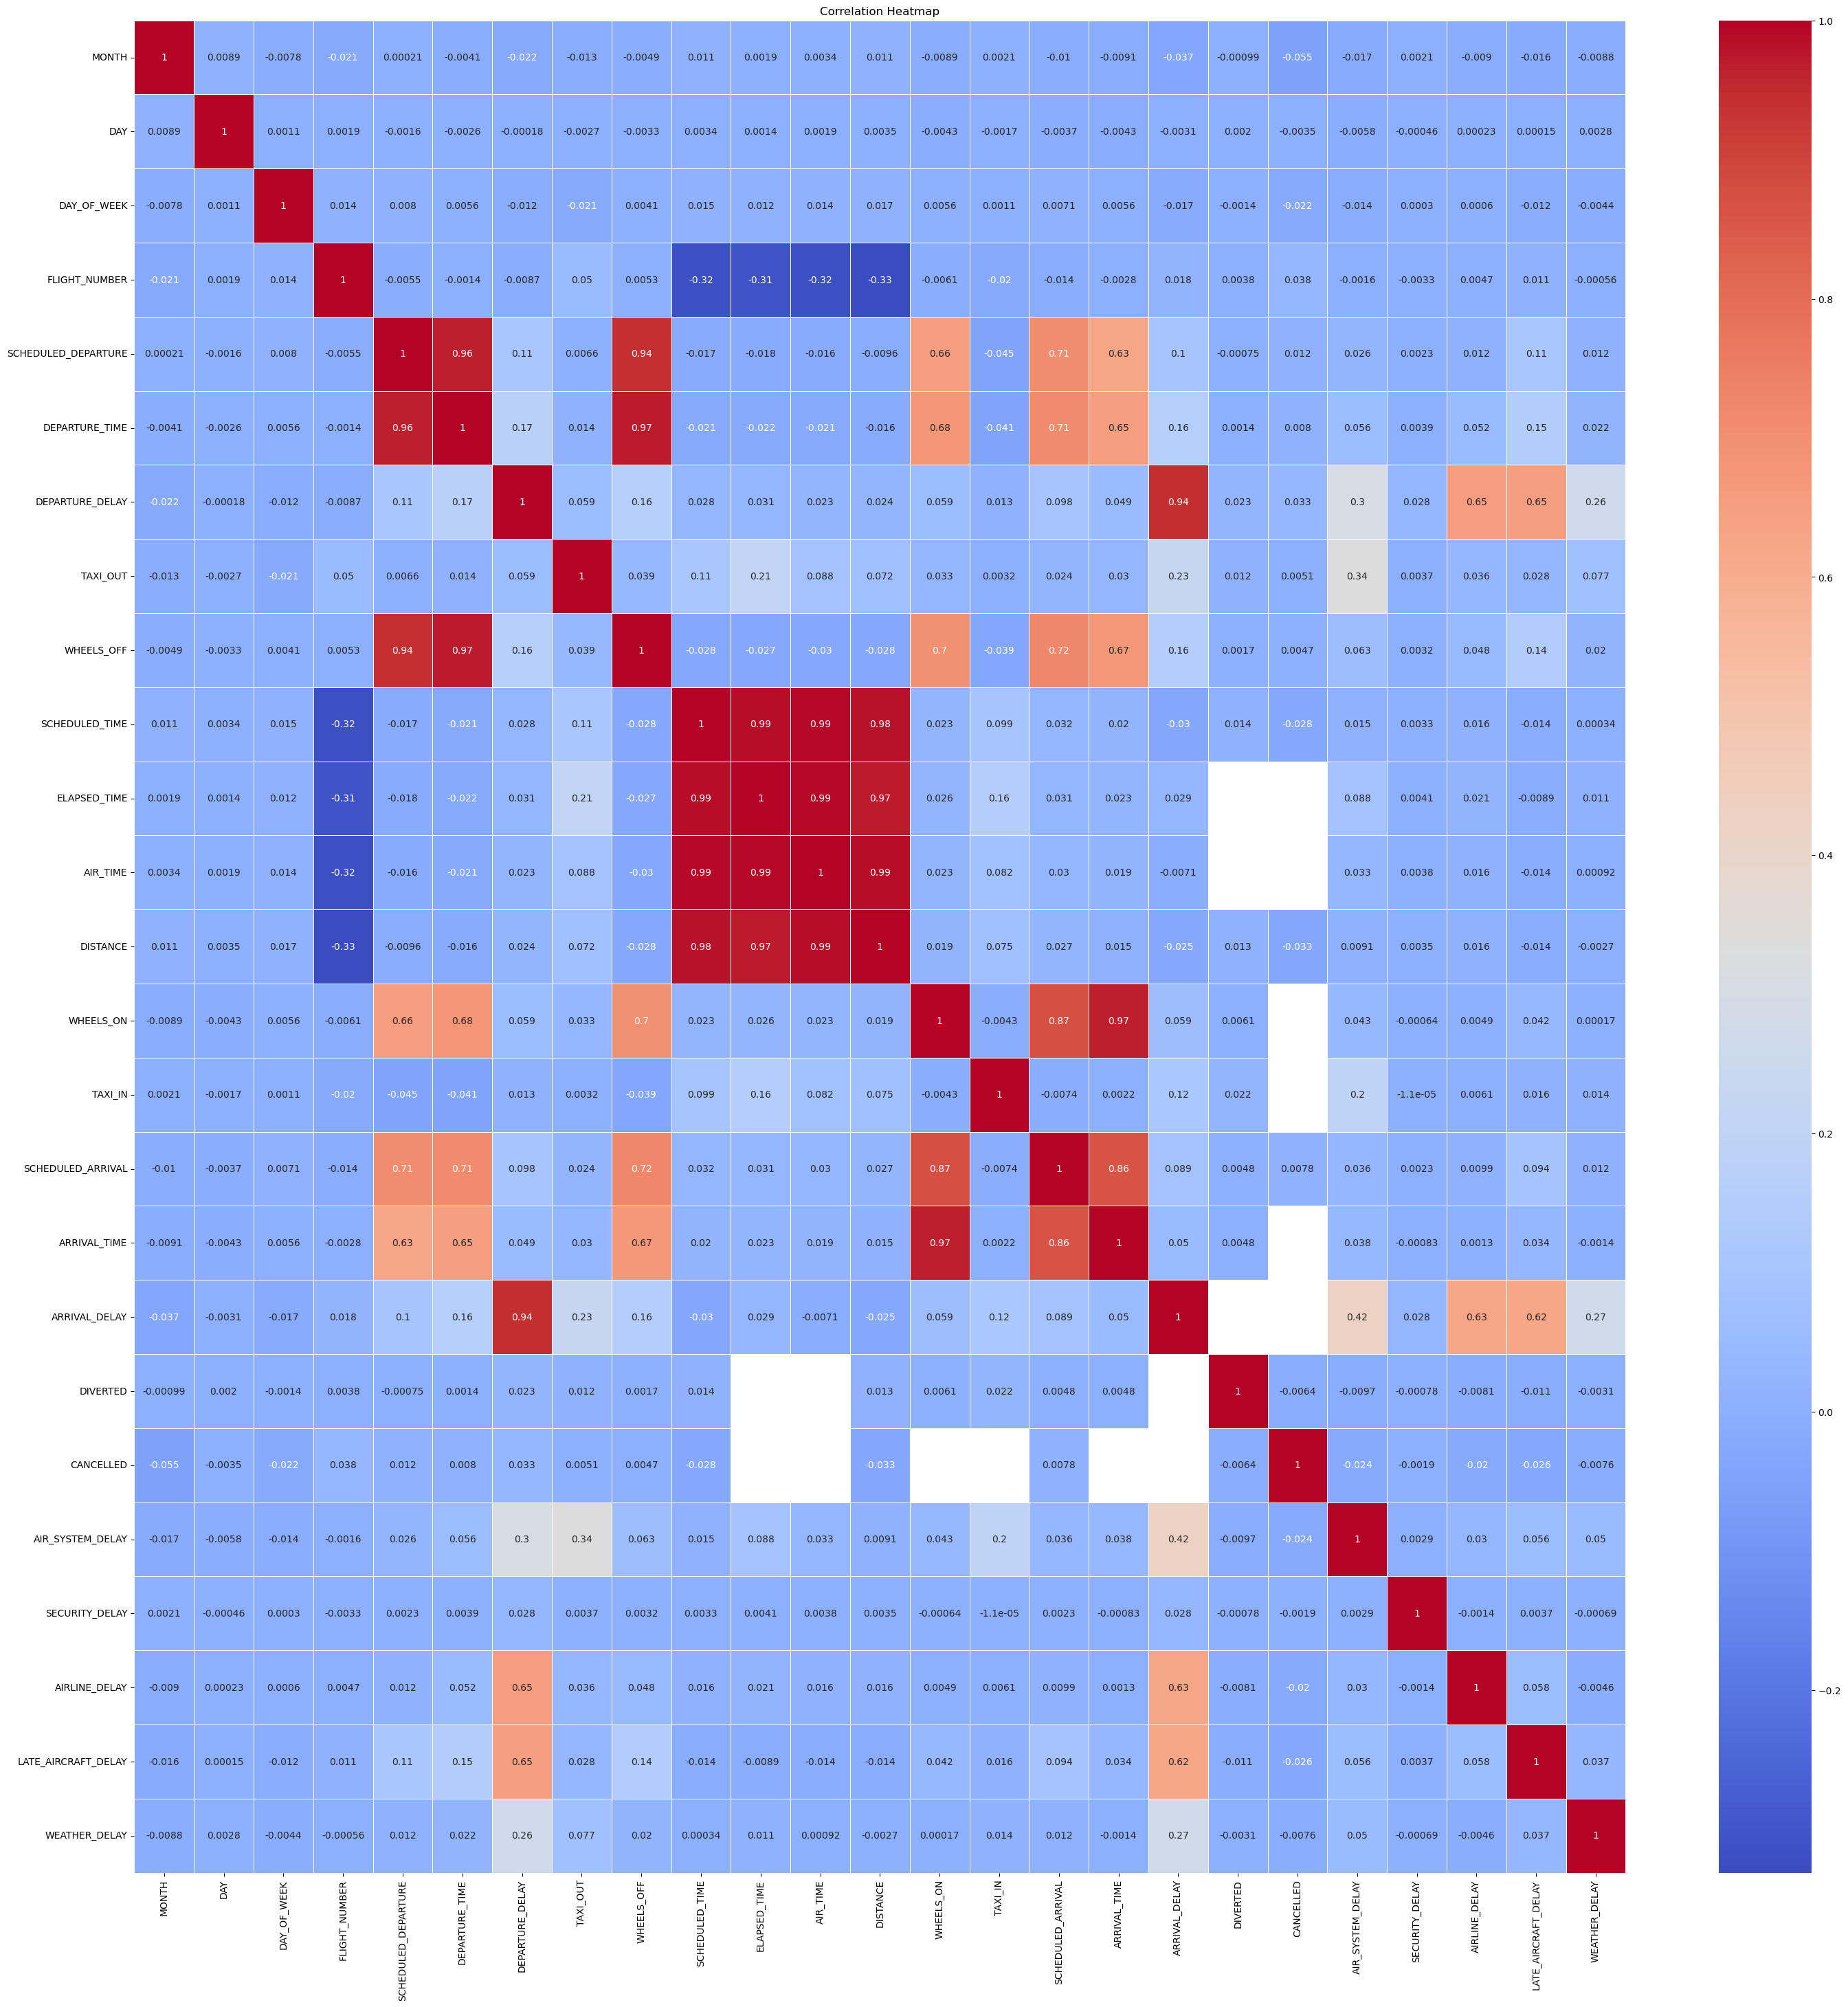

In [36]:
data.drop('YEAR', axis = 1)
numeric_data = data.select_dtypes(include=np.number)
numeric_corr = numeric_data.corr()
plt.figure(figsize=(35, 35))
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [37]:
# Correlation Heatmap Interpretation

# The heatmap illustrates the linear relationships between numerical variables using Pearson's correlation coefficient (-1 to +1).

# Most variables exhibit weak correlations, indicating that they providedistinct information and are not strongly linearly related.

# Scheduled_Time, Elapsed_Time, Air_Time, and Distance have very strong positive correlations (0.96–0.99). These variables all represent flight duration,
#  indicating multicollinearity and redundant information.

# Scheduled_Departure, Departure_Time, and Wheels_Off are strongly positively correlated (0.91–0.97), as they describe consecutive stages of the departure
# process.

# Wheels_On, Scheduled_Arrival, and Arrival_Time also exhibit strong positive correlations (0.77–0.96), reflecting the close relationship between landing and arrival at the gate.

# Departure_Delay and Arrival_Delay have a very strong positive correlation (0.95), indicating that flights departing late are highly likely to arrive late.

# Airline_Delay and Late_Aircraft_Delay show moderate positive correlations (approximately 0.58–0.61) with both Departure_Delay and Arrival_Delay,
# suggesting they are important contributors to flight delays.

# Taxi_Out has a moderate positive correlation (0.41) with Air_System_Delay, implying that airport congestion and air traffic restrictions contribute
# to longer taxi-out times.

# Weather_Delay has weak positive correlations with both Departure_Delay and Arrival_Delay, indicating that weather affects only a subset of flights.

# Security_Delay has negligible correlations with almost all variables, suggesting that security-related delays are rare.

# Flight_Number has very weak correlations with most variables, confirming that it behaves as an identifier rather than a meaningful numerical feature.

# Calendar variables such as Month, Day, and Day_of_Week exhibit weak correlations with operational variables, indicating limited linear relationships.

# Diverted and Cancelled have near-zero correlations with most variables, primarily because these events are rare.

# The strongest negative correlation is between Day and Day_of_Week (-0.48), while most other negative correlations are weak and not practically significant.

# Overall, the heatmap reveals strong relationships among flight duration and timing variables, while most other variables remain weakly correlated.
# Highly correlated variables (Distance, Air_Time, Scheduled_Time, and Elapsed_Time) may introduce multicollinearity in regression models,
# although this is generally less problematic for tree-based algorithms.

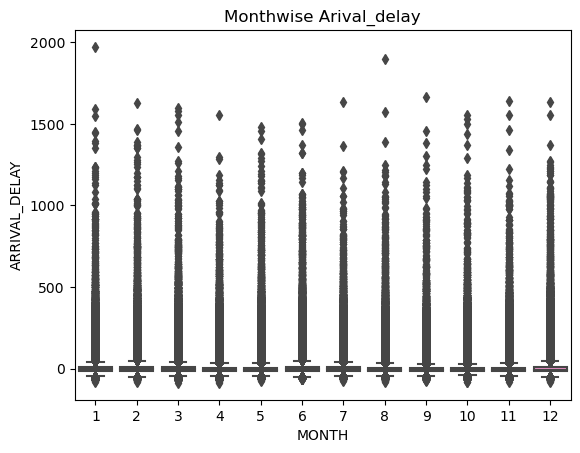

In [43]:
sns.boxplot(data=data, x='MONTH', y='ARRIVAL_DELAY')
plt.title("Monthwise Arival_delay")
plt.show()

In [ ]:
# Month vs Arrival Delay

# The boxplot compares the distribution of arrival delays across all 12 months.

# The median arrival delay is close to 0 minutes for every month,
# indicating that most flights arrive on time or experience only minor delays regardless of the month.

# The interquartile range (IQR) is relatively small and similar across
# all months, suggesting that the majority of flights have comparable arrival delay distributions throughout the year.

# Every month contains numerous positive outliers, with some arrival delays exceeding 1500–1900 minutes. These represent rare but genuine
# operational disruptions, such as severe weather, technical issues, airport congestion, or aircraft scheduling problems.

# Negative arrival delays are also observed, indicating that some flights arrived earlier than their scheduled arrival times.

# No month exhibits a noticeably higher median or substantially wider
# spread than the others. This suggests that arrival delays are fairly
# consistent throughout the year, although extreme delay events occur in every month.

# Overall, the plot indicates that while most flights arrive close to
# schedule, occasional extreme delays are present across all months.

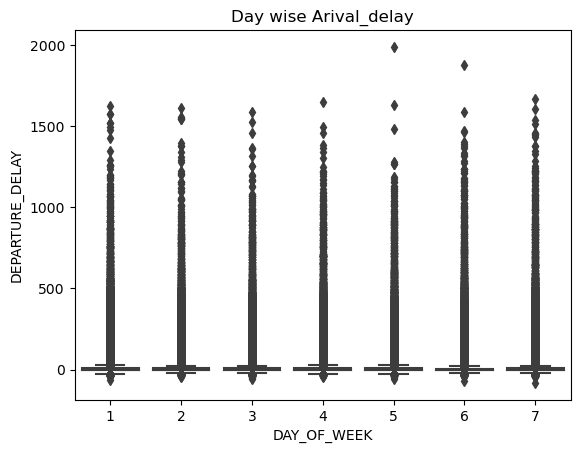

In [44]:
sns.boxplot(data=data , x='DAY_OF_WEEK', y='DEPARTURE_DELAY')
plt.title("Day wise Arival_delay")
plt.show()

In [ ]:
#Day of Week vs Departure Delay

# The boxplot compares the distribution of departure delays across the seven days of the week.

# The median departure delay is close to 0 minutes for all days,
# indicating that most flights depart on time or experience only minor delays regardless of the day of the week.

# The interquartile range (IQR) is relatively small and similar for
# all seven days, suggesting that the typical departure delay does not vary significantly throughout the week.

# Numerous positive outliers are present on every day, with some departure delays reaching nearly 2000 minutes. These represent
# rare but genuine operational disruptions such as severe weather, technical issues, airport congestion, or aircraft scheduling problems.

# Negative departure delays are also observed, indicating that some flights departed earlier than their scheduled departure times.

# Although Days 5 and 6 show a few of the largest extreme delays, their median and IQR are comparable to the other days. Therefore,
# there is no clear evidence that any particular day of the week consistently experiences higher departure delays.

# Overall, the distribution of departure delays remains fairly consistent across all days of the week, while occasional extreme
# delays occur on every day.

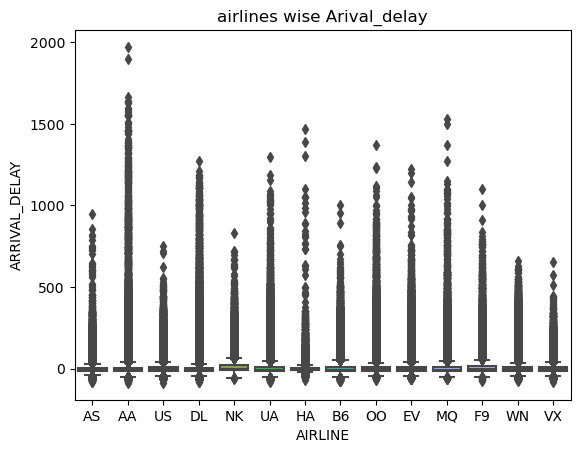

In [45]:
sns.boxplot(data=data, x='AIRLINE', y='ARRIVAL_DELAY')
plt.title("airlines wise Arival_delay")
plt.show()

In [ ]:
# Boxplot: Airline vs Arrival Delay

# The boxplot compares the distribution of arrival delays across different airlines.

# The median arrival delay for most airlines is close to 0 minutes,
# indicating that the majority of flights arrive on time or with only minor delays regardless of the airline.

# The interquartile range (IQR) varies slightly among airlines, suggesting small differences in the consistency of arrival performance.

# Every airline exhibits numerous positive outliers, representing flights with exceptionally long arrival delays. These delays are
# likely caused by factors such as adverse weather conditions, technical issues, airport congestion, or operational disruptions.

# Airlines such as AA, MQ, HA, and OO display some of the largest extreme arrival delays, 
# with outliers exceeding 1400–1900 minutes.

# Airlines such as VX and WN have comparatively fewer and lower
# extreme outliers, indicating relatively fewer exceptionally long delays.

# Negative arrival delays are observed for all airlines, indicating that some flights arrived earlier than their scheduled times.

# Although some airlines show a larger spread of delays than others, the median arrival delays remain similar across airlines.
# Therefore, no airline consistently experiences substantially higher typical arrival delays based on this visualization alone.

# Overall, most flights across all airlines arrive close to schedule, while rare but significant delays occur for every airline.

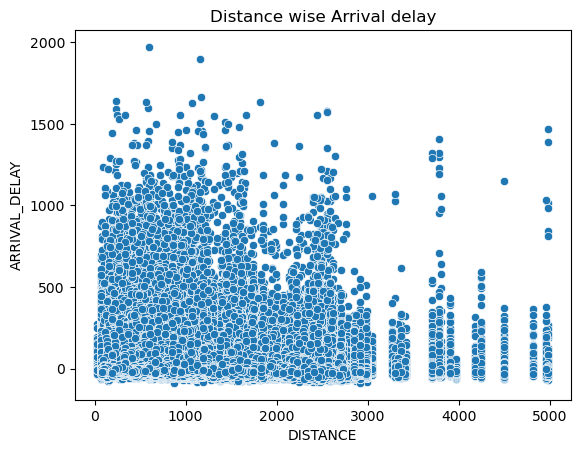

In [47]:
sns.scatterplot(data = data, x='DISTANCE', y='ARRIVAL_DELAY')
plt.title("Distance wise Arrival delay")
plt.show()

In [ ]:
# Scatter Plot: Distance vs Arrival Delay

# The scatter plot illustrates the relationship between flight distance and arrival delay.

# There is no strong linear relationship between distance and arrival delay.
# Flights of both short and long distances experience a wide range of arrival delays.

# Most flights have arrival delays close to 0 minutes regardless of the
# distance travelled, indicating that the majority of flights arrive on time or with only minor delays.

# Several extreme positive delays (exceeding 1000 minutes) are observed
# across different flight distances. These represent rare operational
# disruptions such as severe weather, technical issues, airport congestion, or aircraft scheduling problems.

# Short- and medium-distance flights appear to have a higher concentration  of observations because these routes are more common in the dataset.

# Longer-distance flights are fewer in number, resulting in a lower density of points at greater distances.

# No clear upward or downward trend is observed, suggesting that flight distance alone is not a strong predictor of arrival delay.

# Overall, arrival delays occur across all flight distances, implying that factors such as weather conditions, airport 
# congestion, airline operations, and aircraft availability have a greater influence on delays than the distance travelled.

D:\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_

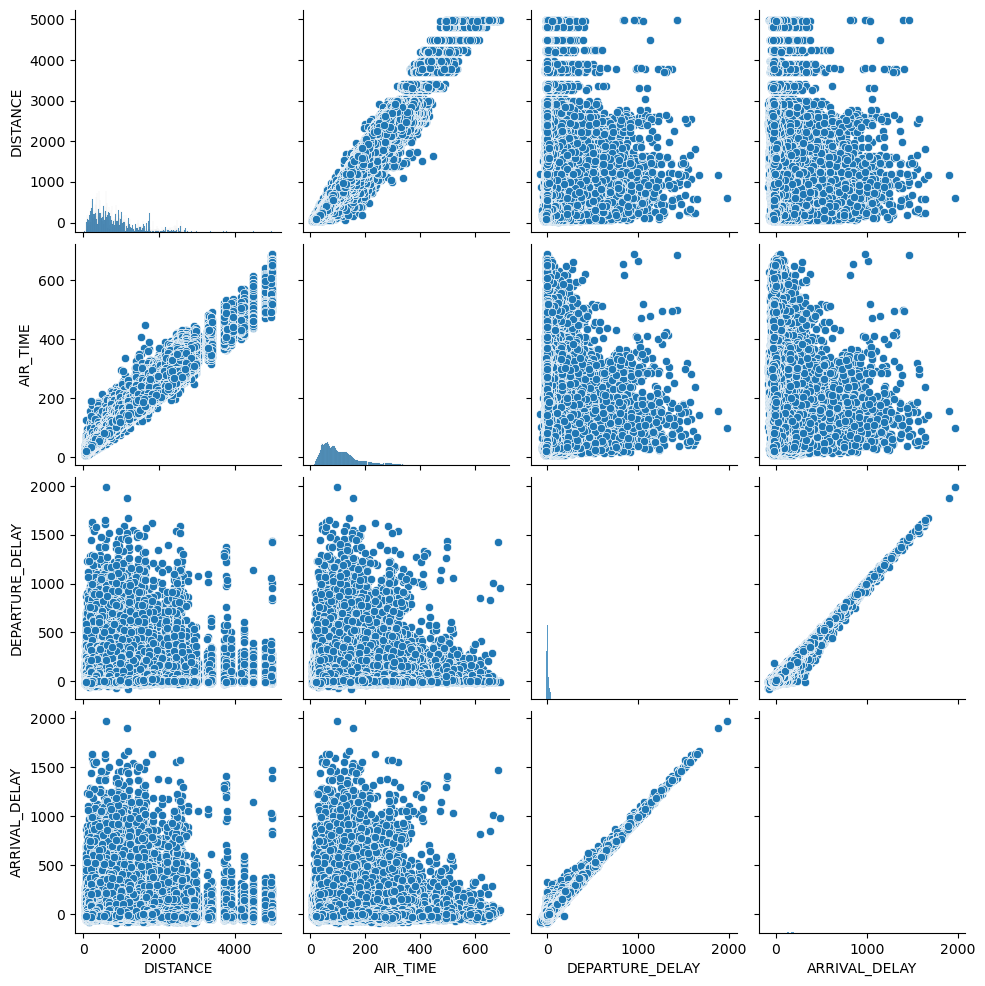

In [50]:
cols = [
    'DISTANCE',
    'AIR_TIME',
    'DEPARTURE_DELAY',
    'ARRIVAL_DELAY'
]

sns.pairplot(data[cols])
plt.show()

In [ ]:
# Pair Plot Interpretation

# Distance and Air Time exhibit a strong positive linear relationship, indicating that longer flights 
# generally have longer air travel times.

# Departure Delay and Arrival Delay show an almost perfect positive linear relationship, suggesting that flights 
# departing late are highly likely to arrive late. This indicates that departure delay is a strong predictor of arrival delay.

# Distance has little or no clear relationship with Departure Delay, as flights of varying distances experience both short and long delays.

# Similarly, Distance shows no significant relationship with Arrival Delay,
# indicating that flight distance alone does not determine whether a flight will arrive late.

# Air Time also shows a weak relationship with both Departure Delay
# and Arrival Delay, suggesting that the duration of the flight has  minimal influence on flight delays.

# The diagonal histograms reveal that Distance and Air Time are right-skewed, with a higher concentration of short-
# and medium-distance flights.

# Departure Delay and Arrival Delay are highly right-skewed, with most flights experiencing little or no delay and
# a small number of flights exhibiting extremely large delays.

# Several extreme outliers are observed in the delay variables. These likely represent genuine operational disruptions such as
# adverse weather, technical issues, airport congestion, or aircraft scheduling problems rather than data entry errors.

# Overall, the pair plot confirms that Distance is strongly associated
# with Air Time, while Departure Delay is the strongest predictor of Arrival Delay. In contrast, Distance and Air 
# Time have little direct influence on flight delays.